# XG Boosted Trees
To predict the diabetes in patients

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
df=pd.read_csv("input_data/diabetes.csv")

In [3]:
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [4]:
df.Outcome.value_counts()

0    500
1    268
Name: Outcome, dtype: int64

## Data cleaning

All the variables seem as numerical. Let us look at the variable types

In [5]:
df.dtypes

Pregnancies                   int64
Glucose                       int64
BloodPressure                 int64
SkinThickness                 int64
Insulin                       int64
BMI                         float64
DiabetesPedigreeFunction    float64
Age                           int64
Outcome                       int64
dtype: object

Now, let us see if there are any null values

In [6]:
for i in df.columns:
    print (i," : ",df[i].isna().sum())

Pregnancies  :  0
Glucose  :  0
BloodPressure  :  0
SkinThickness  :  0
Insulin  :  0
BMI  :  0
DiabetesPedigreeFunction  :  0
Age  :  0
Outcome  :  0


There are no null values

In [7]:
df.groupby('Outcome').agg('mean')

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
Outcome,,,,,,,,
0,3.298000,109.980000,68.184000,19.664000,68.792000,30.304200,0.429734,31.190000
1,4.865672,141.257463,70.824627,22.164179,100.335821,35.142537,0.550500,37.067164


In [8]:
df.groupby('Outcome').agg(['min','max'])

Pregnancies     Glucose      BloodPressure      SkinThickness      \
                min max     min  max           min  max           min max   
Outcome                                                                     
0                 0  13       0  197             0  122             0  60   
1                 0  17       0  199             0  114             0  99   

        Insulin       BMI       DiabetesPedigreeFunction        Age      
            min  max  min   max                      min    max min max  
Outcome                                                                  
0             0  744  0.0  57.3                    0.078  2.329  21  81  
1             0  846  0.0  67.1                    0.088  2.420  21  70

The value 0 is repeating even for factors such as BMI which cannot be zero. So, the values of zero seem like they are missing values. 
This excludes the Pregnancies variable where the values of zero is possible.

In [9]:
for i in df.columns:
    print(i)
    print(' =0 : ', df.loc[df[i]==0].shape[0])
    print('!=0 : ', df.loc[df[i]!=0].shape[0])

Pregnancies
 =0 :  111
!=0 :  657
Glucose
 =0 :  5
!=0 :  763
BloodPressure
 =0 :  35
!=0 :  733
SkinThickness
 =0 :  227
!=0 :  541
Insulin
 =0 :  374
!=0 :  394
BMI
 =0 :  11
!=0 :  757
DiabetesPedigreeFunction
 =0 :  0
!=0 :  768
Age
 =0 :  0
!=0 :  768
Outcome
 =0 :  500
!=0 :  268


In [10]:
df.loc[df['Insulin']==0]['Outcome'].value_counts()

0    236
1    138
Name: Outcome, dtype: int64

Insulin=0 is possible so will not be changing those values to null. For all the other values, changing to null

In [11]:
df.loc[df['Glucose']==0,'Glucose']=np.NaN
df.loc[df['BloodPressure']==0,'BloodPressure']=np.NaN
df.loc[df['SkinThickness']==0,'SkinThickness']=np.NaN
df.loc[df['BMI']==0,'BMI']=np.NaN

## Data Visualisation

Creating a box plot for all the variables, with breakdown on the Outcome

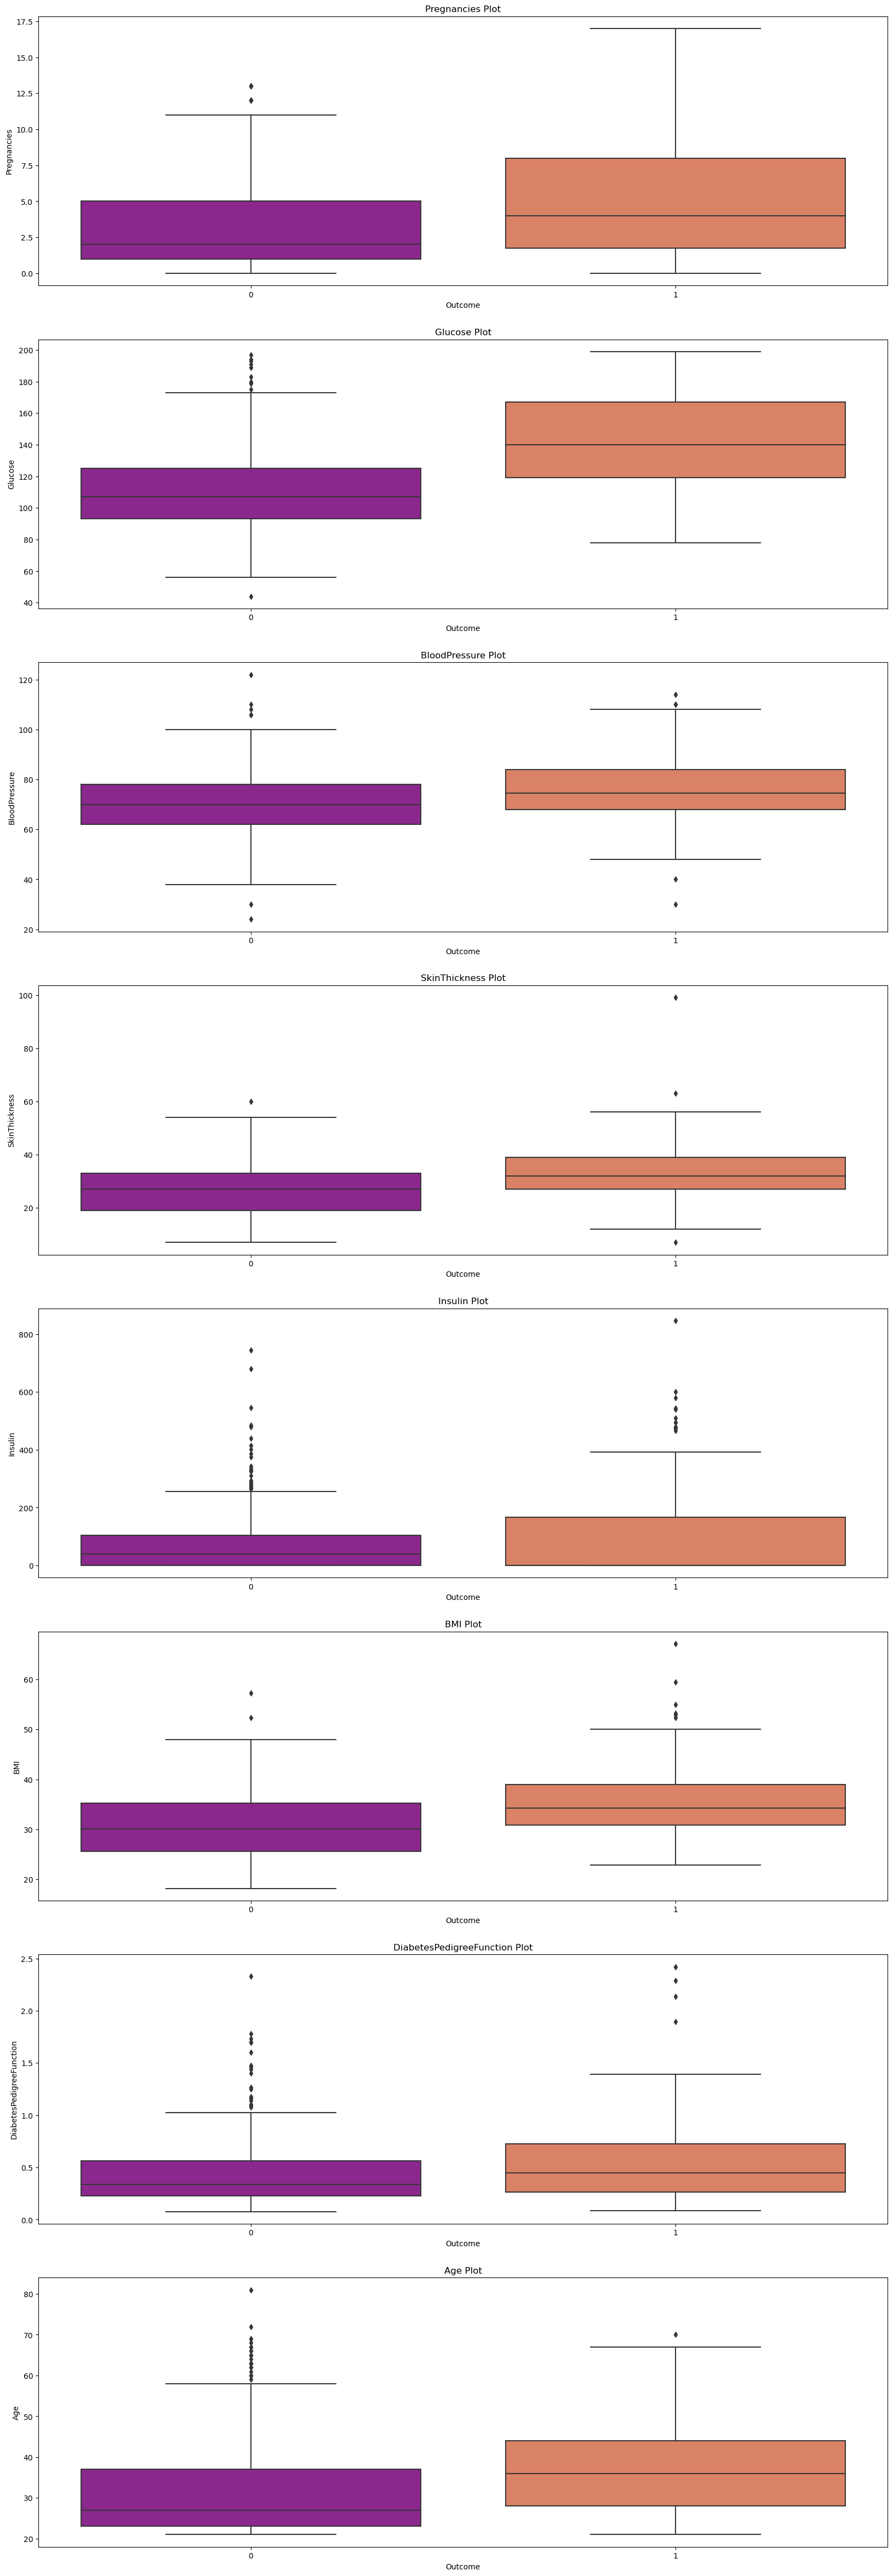

In [12]:
cols=[c for c in df.columns if c!='Outcome']
l=len(cols)

plt.figure(figsize=(20,60))
for i in range(l):
    plt.subplot(l,1,i+1)
    sns.boxplot(x=df.Outcome, y=df[cols[i]],palette=("plasma"))
    plt.title(cols[i]+' Plot')

Finding the correlation among varibles using Heat Map

In [13]:
def correlation(df):
    corr=df.corr().round(2)
    plt.figure(figsize=(20,20))
    sns.heatmap(corr,annot=True, fmt=".2f", cmap="coolwarm", cbar=True)
    plt.title('Correlation Heatmap')
    plt.show()

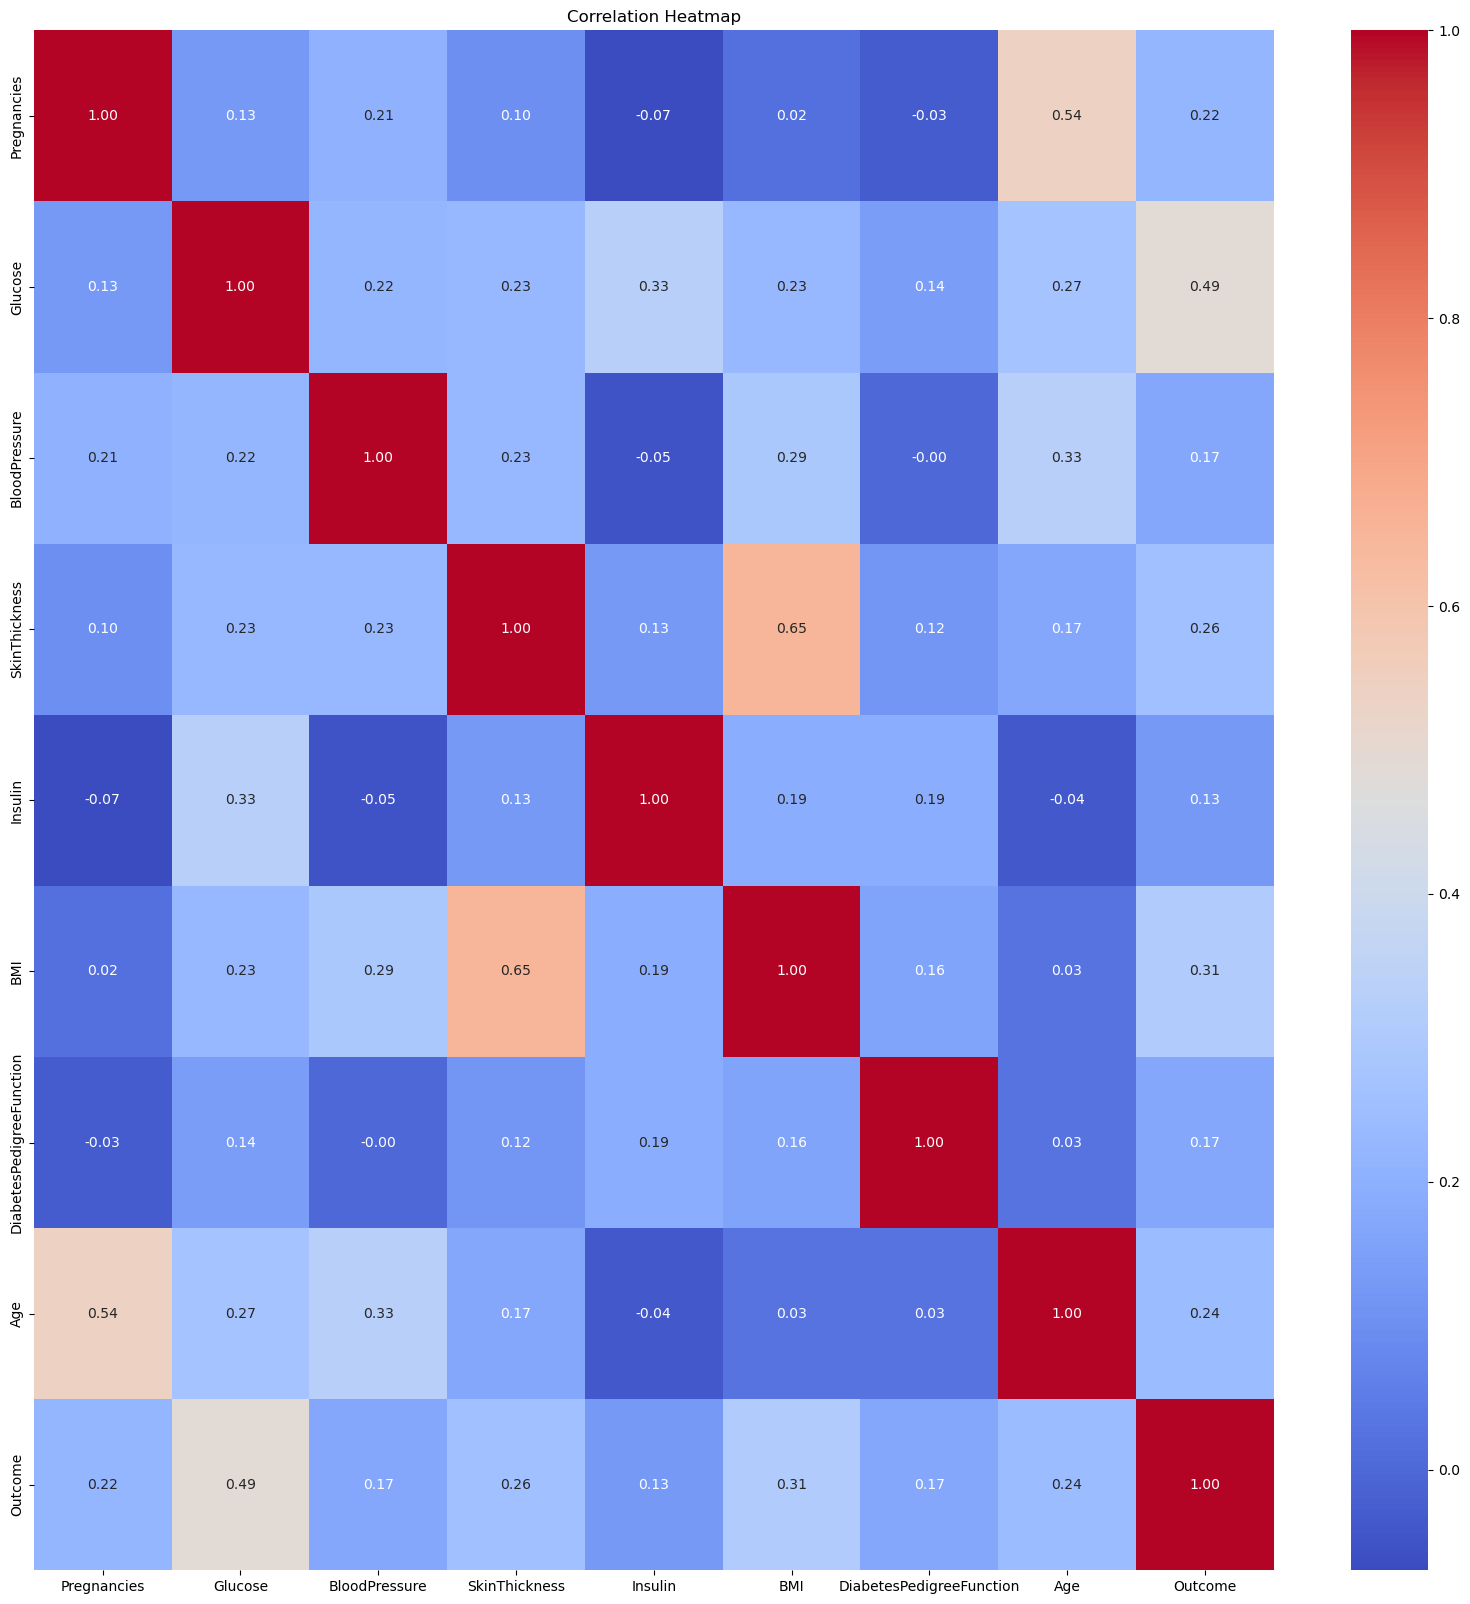

In [14]:
correlation(df)

None of the variables have high correlation among each other. So, we can move forward.

## Data Preperation

Standardisation of all the numerical Values

In [15]:
from sklearn.preprocessing import MinMaxScaler

In [16]:
scaler=MinMaxScaler()

In [17]:
df_trans=df[cols]
df_trans=pd.DataFrame(scaler.fit_transform(df_trans),columns=cols,index=df_trans.index)

In [18]:
df[cols]=df_trans[cols]

In [19]:
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,0.352941,0.670968,0.489796,0.304348,0.000000,0.314928,0.234415,0.483333,1
1,0.058824,0.264516,0.428571,0.239130,0.000000,0.171779,0.116567,0.166667,0
2,0.470588,0.896774,0.408163,NaN,0.000000,0.104294,0.253629,0.183333,1
3,0.058824,0.290323,0.428571,0.173913,0.111111,0.202454,0.038002,0.000000,0
4,0.000000,0.600000,0.163265,0.304348,0.198582,0.509202,0.943638,0.200000,1


## Train test Split

In [20]:
from sklearn.model_selection import train_test_split

In [21]:
np.random.seed(20)

In [22]:
df_train,df_test=train_test_split(df,train_size=0.7,test_size=0.3,random_state=100)

In [23]:
y_train=df_train.pop('Outcome')
x_train=df_train

In [24]:
y_test=df_test.pop('Outcome')
x_test=df_test

## Building the model

In [25]:
from xgboost import XGBClassifier
import xgboost as xgb

In [26]:
model=XGBClassifier()

In [27]:
dtrain = xgb.DMatrix(x_train, label=y_train)

In [28]:
params = {
    'objective': 'binary:logistic',
    'eval_metric': 'auc',
    'max_depth': 5,
    'eta': 0.05,
    'subsample': 0.7,
    'colsample_bytree': 0.8,
    'seed': 100
}

In [29]:
cv_results = xgb.cv(
    params=params,
    dtrain=dtrain,
    num_boost_round=500,        # max rounds
    nfold=5,                    # 5-fold CV
    metrics='auc',
    early_stopping_rounds=20,   # stop if no improvement in 20 rounds
    as_pandas=True,
    seed=100,
    verbose_eval=10
)

[0]	train-auc:0.88196+0.01207	test-auc:0.78534+0.04995
[10]	train-auc:0.95445+0.00387	test-auc:0.84418+0.02643
[20]	train-auc:0.96560+0.00202	test-auc:0.84083+0.02857
[29]	train-auc:0.97035+0.00135	test-auc:0.84221+0.03130


In [30]:
print(cv_results.head())
print("Best number of boosting rounds:", cv_results.shape[0])
best_n_estimators = cv_results.shape[0]

   train-auc-mean  train-auc-std  test-auc-mean  test-auc-std
0        0.881961       0.012067       0.785338      0.049950
1        0.920000       0.006294       0.804585      0.049594
2        0.928406       0.009536       0.810682      0.046499
3        0.940668       0.006900       0.816459      0.044274
4        0.942982       0.004790       0.823336      0.037754
Best number of boosting rounds: 10


In [31]:
model = xgb.XGBClassifier(
    n_estimators=best_n_estimators,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.7,
    colsample_bytree=0.8,
    reg_lambda=2,
    reg_alpha=1,
    gamma=0.3,
    eval_metric='auc',
    random_state=100
)

In [32]:
model.fit(x_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='auc', feature_types=None,
              feature_weights=None, gamma=0.3, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.05, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=5,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=10,
              n_jobs=None, num_parallel_tree=None, ...)

## Prediction and evaluation

In [33]:
from sklearn.metrics import confusion_matrix,roc_auc_score, roc_curve
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

In [34]:
#Train
y_train_pred_proba=model.predict_proba(x_train)[:,1]

#Test
y_test_pred_proba=model.predict_proba(x_test)[:,1]

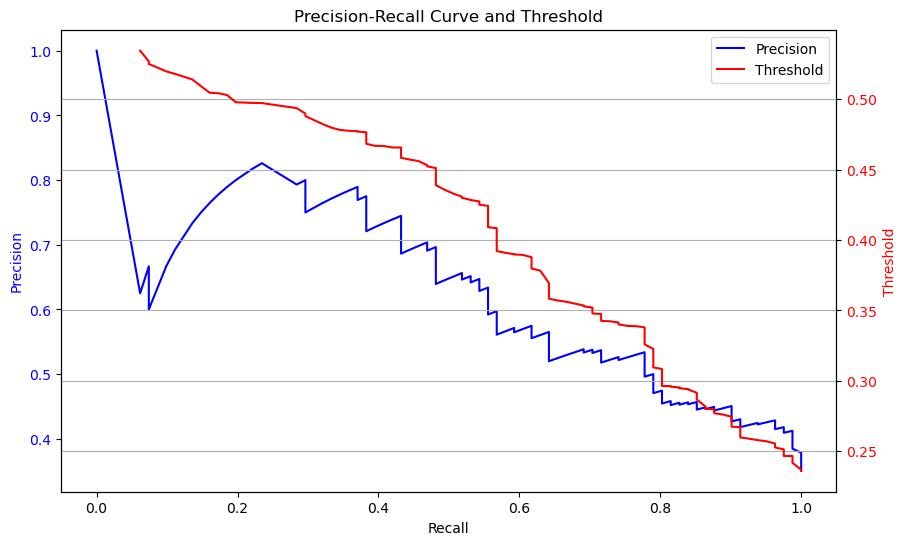

In [35]:
from sklearn.metrics import precision_recall_curve

precision, recall, thresholds = precision_recall_curve(y_test, y_test_pred_proba)

# Create a figure with two y-axes
fig, ax1 = plt.subplots(figsize=(10, 6))
ax2 = ax1.twinx()

# Plot precision vs recall
ax1.plot(recall, precision, 'b-', label='Precision')
ax1.set_xlabel('Recall')
ax1.set_ylabel('Precision', color='b')
ax1.tick_params(axis='y', labelcolor='b')

# Plot thresholds vs recall
ax2.plot(recall[:-1], thresholds, 'r-', label='Threshold')
ax2.set_ylabel('Threshold', color='r')
ax2.tick_params(axis='y', labelcolor='r')

# Set the title and display the legend
plt.title('Precision-Recall Curve and Threshold')
fig.legend(loc="upper right", bbox_to_anchor=(1,1), bbox_transform=ax1.transAxes)

# Display the grid
plt.grid(True)

# Show the plot
plt.show()

In [36]:
#selecting best threshold

thres_df=pd.DataFrame(
{
    'Precision':precision,'Recall': recall,'Threshold': np.append(thresholds, 1)
}
)
thres_df.head(5)

,Precision,Recall,Threshold
0,0.350649,1.000000,0.236218
1,0.378505,1.000000,0.236884
2,0.384615,0.987654,0.241840
3,0.386473,0.987654,0.242019
4,0.390244,0.987654,0.243908


In [37]:
# to find the highest precision for recall> 0.5
thres_df.loc[thres_df['Recall']>0.5,'Precision'].max()

0.65625

In [38]:
thres_df.loc[(thres_df['Recall']>0.5) & (thres_df['Precision']> 0.6562)][['Threshold','Recall']]


,Threshold,Recall
136,0.430714,0.518519


For getting the highest precision, threshold of around 0.455 should be used but that would lead to very low recall. So, in order to get a higher recall value and good precision, threshold of 0.430714 should be used

In [39]:
threshold = 0.430714

y_train_pred = (y_train_pred_proba >= threshold).astype(int)
y_test_pred = (y_test_pred_proba >= threshold).astype(int)

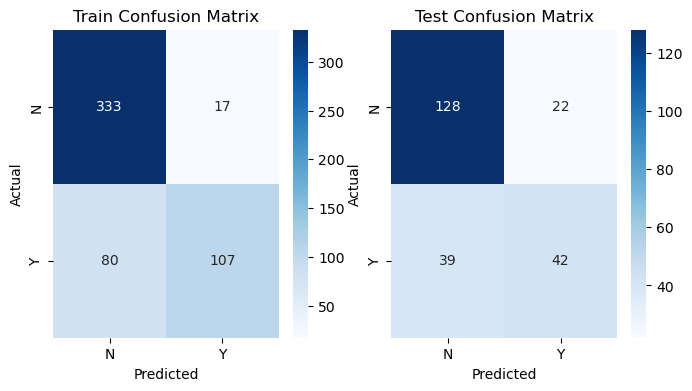

In [40]:
confusion_matrix_train=confusion_matrix(y_train,y_train_pred)
confusion_matrix_test=confusion_matrix(y_test,y_test_pred)

plt.figure(figsize=(8, 4))

plt.subplot(1,2,1)
sns.heatmap(confusion_matrix_train, annot=True, fmt='d', cmap='Blues', xticklabels=['N', 'Y'], yticklabels=['N', 'Y'])
plt.title('Train Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')

plt.subplot(1,2,2)
sns.heatmap(confusion_matrix_test, annot=True, fmt='d', cmap='Blues', xticklabels=['N', 'Y'], yticklabels=['N', 'Y'])
plt.title('Test Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')

plt.show()

In [41]:
print('Train Metrices')
print("Accuracy :", accuracy_score(y_train, y_train_pred))
print("Precision:", precision_score(y_train, y_train_pred))
print("Recall   :", recall_score(y_train, y_train_pred))
print("F1 Score :", f1_score(y_train, y_train_pred))
print('')
print('Test Metrices')
print("Accuracy :", accuracy_score(y_test, y_test_pred))
print("Precision:", precision_score(y_test, y_test_pred))
print("Recall   :", recall_score(y_test, y_test_pred))
print("F1 Score :", f1_score(y_test, y_test_pred))

Train Metrices
Accuracy : 0.819366852886406
Precision: 0.8629032258064516
Recall   : 0.5721925133689839
F1 Score : 0.6881028938906752

Test Metrices
Accuracy : 0.7359307359307359
Precision: 0.65625
Recall   : 0.5185185185185185
F1 Score : 0.5793103448275861
